In [1]:
"""
ColBERT-style late interaction retrieval for proteins using ESM-2 35M.
Supports either SCOPe or Pfam as the dataset.

Pipeline:
  1. Load proteins (SCOPe superfamilies or Pfam clans as homology labels).
  2. Split by group so train/test groups are disjoint.
  3. Subsample test set for tractable evaluation.
  4. Fine-tune last 3 layers of ESM-2 35M with ColBERT MaxSim + InfoNCE.
  5. Evaluate retrieval Recall@k.
  6. Run baselines for comparison:
     - Trained CLS single-vector (ColBERT paper Model [A])
     - MinHash Jaccard (sequence-only floor)
     - MMseqs2 (state-of-the-art sequence search)
     - Mean-pool ESM-2 650M frozen
"""

# =============================================================================
# Cell 1: Install + imports
# =============================================================================
# !pip install -q --upgrade "transformers==4.46.3" "tokenizers>=0.20" \
#   "huggingface_hub>=0.26" datasketch
# IMPORTANT: after install, Runtime > Restart session, then run the rest.

import os
import re
import gzip
import random
import shutil
import subprocess
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



Using device: cuda


In [2]:

# =============================================================================
# Cell 2: Choose dataset
# =============================================================================
DATASET = "scope"   # "scope" or "pfam"


@dataclass
class Protein:
    sid: str
    sequence: str
    superfamily: str            # SCOPe superfamily OR Pfam clan
    family: str = ""
    family_name: str = ""



In [3]:

# =============================================================================
# Cell 3a: SCOPe loader
# =============================================================================
def load_scope():
    SCOPE_URL = (
        "https://scop.berkeley.edu/downloads/scopeseq-2.08/"
        "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa"
    )
    SCOPE_PATH = "astral_scope_40_2.08.fa"
    if not os.path.exists(SCOPE_PATH):
        print(f"Downloading {SCOPE_URL} ...")
        subprocess.run(["curl", "-kL", "-o", SCOPE_PATH, SCOPE_URL], check=True)
    print(f"  {SCOPE_PATH}: {os.path.getsize(SCOPE_PATH)/1e6:.1f} MB")

    proteins = []
    sid, sccs, seq_chunks = None, None, []

    def flush():
        if sid is None:
            return
        seq = "".join(seq_chunks).upper()
        if re.fullmatch(r"[ACDEFGHIKLMNPQRSTVWY]+", seq) and 20 <= len(seq) <= 512:
            sf = ".".join(sccs.split(".")[:3])
            proteins.append(Protein(
                sid=sid, sequence=seq, superfamily=sf, family=sccs,
            ))

    with open(SCOPE_PATH) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                flush()
                parts = line[1:].split()
                sid = parts[0]
                sccs = parts[1] if len(parts) > 1 else "x.x.x.x"
                seq_chunks = []
            else:
                seq_chunks.append(line)
        flush()
    print(f"Parsed {len(proteins)} SCOPe proteins")
    return proteins


# =============================================================================
# Cell 3b: Pfam loader
# =============================================================================
def load_pfam(max_per_family: int = 50):
    PFAM_BASE = "https://ftp.ebi.ac.uk/pub/databases/Pfam/current_release"
    PFAM_SEED_GZ = "Pfam-A.seed.gz"
    PFAM_CLANS_GZ = "Pfam-A.clans.tsv.gz"
    for fname in [PFAM_SEED_GZ, PFAM_CLANS_GZ]:
        if not os.path.exists(fname):
            url = f"{PFAM_BASE}/{fname}"
            print(f"Downloading {url} ...")
            subprocess.run(["curl", "-kL", "-o", fname, url], check=True)
        print(f"  {fname}: {os.path.getsize(fname)/1e6:.1f} MB")

    fam2clan = {}
    with gzip.open(PFAM_CLANS_GZ, "rt", encoding="latin-1") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2 and parts[1]:
                fam2clan[parts[0]] = parts[1]
    print(f"Loaded {len(fam2clan)} family->clan mappings")

    proteins = []
    family_acc, family_id = None, None
    seqs = []
    n_blocks, n_clan_blocks = 0, 0

    with gzip.open(PFAM_SEED_GZ, "rt", encoding="latin-1") as f:
        for line in f:
            line = line.rstrip()
            if line.startswith("# STOCKHOLM"):
                family_acc, family_id, seqs = None, None, []
            elif line.startswith("#=GF AC"):
                family_acc = line.split()[2].split(".")[0]
            elif line.startswith("#=GF ID"):
                family_id = line.split(maxsplit=2)[2]
            elif line == "//":
                n_blocks += 1
                if family_acc and family_acc in fam2clan:
                    n_clan_blocks += 1
                    clan = fam2clan[family_acc]
                    chosen = seqs[:max_per_family]
                    for sid, gapped in chosen:
                        ungapped = re.sub(r"[^A-Za-z]", "", gapped).upper()
                        ungapped = re.sub(r"[^ACDEFGHIKLMNPQRSTVWY]", "", ungapped)
                        if 20 <= len(ungapped) <= 512:
                            proteins.append(Protein(
                                sid=sid, sequence=ungapped,
                                superfamily=clan, family=family_acc,
                                family_name=family_id or "",
                            ))
                family_acc, family_id, seqs = None, None, []
            elif line.startswith("#") or not line:
                continue
            else:
                parts = line.split(None, 1)
                if len(parts) == 2:
                    seqs.append((parts[0], parts[1]))

    n_clans = len(set(p.superfamily for p in proteins))
    n_fams = len(set(p.family for p in proteins))
    print(f"Total family blocks: {n_blocks}; in a clan: {n_clan_blocks}")
    print(f"Kept {len(proteins)} sequences from {n_fams} families in {n_clans} clans")
    return proteins



In [4]:

# =============================================================================
# Cell 4: Run loader
# =============================================================================
if DATASET == "scope":
    proteins = load_scope()
elif DATASET == "pfam":
    proteins = load_pfam(max_per_family=50)
else:
    raise ValueError(f"Unknown DATASET: {DATASET!r}")

lengths = [len(p.sequence) for p in proteins]
sf_sizes = Counter(p.superfamily for p in proteins)
print(f"\nLength: median={int(np.median(lengths))}, max={max(lengths)}")
print(f"Groups: {len(sf_sizes)}, "
      f"largest={max(sf_sizes.values())}, median={int(np.median(list(sf_sizes.values())))}")


# =============================================================================
# Cell 5: Train/test split (disjoint groups)
# =============================================================================
def split_by_superfamily(proteins, test_frac=0.15, min_members=3):
    by_sf = defaultdict(list)
    for p in proteins:
        by_sf[p.superfamily].append(p)
    sfs = [sf for sf, m in by_sf.items() if len(m) >= min_members]
    random.Random(SEED).shuffle(sfs)
    n_test = max(1, int(len(sfs) * test_frac))
    test_sfs = set(sfs[:n_test])
    train_sfs = set(sfs[n_test:])
    train = [p for sf in train_sfs for p in by_sf[sf]]
    test = [p for sf in test_sfs for p in by_sf[sf]]
    print(f"Total groups (>= {min_members} members): {len(sfs)}")
    print(f"Train: {len(train_sfs)} groups, {len(train)} proteins")
    print(f"Test:  {len(test_sfs)} groups, {len(test)} proteins")
    return train, test


train_proteins, test_proteins = split_by_superfamily(
    proteins, test_frac=0.15, min_members=3,
)


# =============================================================================
# Cell 5b: Cap test set size for tractable evaluation
# =============================================================================
MAX_TEST_PROTEINS = 3000

if len(test_proteins) > MAX_TEST_PROTEINS:
    by_sf = defaultdict(list)
    for p in test_proteins:
        by_sf[p.superfamily].append(p)
    rng = random.Random(SEED)
    kept = []
    # First pass: 2 per group (every group gets retrievable positives)
    for sf, members in by_sf.items():
        rng.shuffle(members)
        kept.extend(members[:2])
    # Second pass: random fill up to budget
    leftovers = [p for sf, members in by_sf.items() for p in members[2:]]
    rng.shuffle(leftovers)
    remaining = MAX_TEST_PROTEINS - len(kept)
    if remaining > 0:
        kept.extend(leftovers[:remaining])
    test_proteins = kept
    print(f"Subsampled test set to {len(test_proteins)} proteins "
          f"across {len(set(p.superfamily for p in test_proteins))} groups")


# =============================================================================
# Cell 6: Tokenizer + dataset
# =============================================================================
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
MAX_LEN = 256
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class PairDataset(Dataset):
    def __init__(self, proteins, max_len=MAX_LEN):
        self.proteins = proteins
        self.by_sf = defaultdict(list)
        for i, p in enumerate(proteins):
            self.by_sf[p.superfamily].append(i)
        self.valid_sfs = [sf for sf, idxs in self.by_sf.items() if len(idxs) >= 2]
        self.epoch_size = sum(len(self.by_sf[sf]) for sf in self.valid_sfs)

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        sf = random.choice(self.valid_sfs)
        i, j = random.sample(self.by_sf[sf], 2)
        return self.proteins[i].sequence, self.proteins[j].sequence, sf


def collate_pairs(batch):
    anchors = [b[0] for b in batch]
    positives = [b[1] for b in batch]
    sfs = [b[2] for b in batch]
    enc_a = tokenizer(anchors, padding=True, truncation=True,
                      max_length=MAX_LEN, return_tensors="pt")
    enc_p = tokenizer(positives, padding=True, truncation=True,
                      max_length=MAX_LEN, return_tensors="pt")
    return enc_a, enc_p, sfs


# =============================================================================
# Cell 7: ColBERT model (per-residue, MaxSim)
# =============================================================================
class ProteinColBERT(nn.Module):
    def __init__(self, model_name=MODEL_NAME, proj_dim=128, n_trainable_layers=3):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.proj = nn.Linear(hidden, proj_dim, bias=False)
        self.proj_dim = proj_dim
        self._freeze_all_but_last_n(n_trainable_layers)

    def _freeze_all_but_last_n(self, n):
        for p in self.backbone.parameters():
            p.requires_grad = False
        total = len(self.backbone.encoder.layer)
        for i in range(total - n, total):
            for p in self.backbone.encoder.layer[i].parameters():
                p.requires_grad = True
        if hasattr(self.backbone, "emb_layer_norm_after") and \
                self.backbone.emb_layer_norm_after is not None:
            for p in self.backbone.emb_layer_norm_after.parameters():
                p.requires_grad = True
        for p in self.proj.parameters():
            p.requires_grad = True
        n_t = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_a = sum(p.numel() for p in self.parameters())
        print(f"Trainable: {n_t:,}/{n_a:,} ({100*n_t/n_a:.1f}%)")

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids,
                            attention_mask=attention_mask).last_hidden_state
        emb = self.proj(out)
        return F.normalize(emb, dim=-1)



  astral_scope_40_2.08.fa: 4.3 MB
Parsed 14618 SCOPe proteins

Length: median=149, max=512
Groups: 2020, largest=342, median=2
Total groups (>= 3 members): 849
Train: 722 groups, 10769 proteins
Test:  127 groups, 2314 proteins


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:

# =============================================================================
# Cell 8: MaxSim + InfoNCE
# =============================================================================
def maxsim(q_emb, q_mask, d_emb, d_mask):
    sim = torch.einsum("qtd,bsd->qbts", q_emb, d_emb)
    d_mask_expand = d_mask[None, :, None, :].bool()
    sim = sim.masked_fill(~d_mask_expand, float("-inf"))
    max_over_d = sim.max(dim=-1).values
    q_mask_expand = q_mask[:, None, :].bool()
    max_over_d = max_over_d.masked_fill(~q_mask_expand, 0.0)
    return max_over_d.sum(dim=-1)


def contrastive_loss(scores, temperature=1.0):
    logits = scores / temperature
    labels = torch.arange(scores.size(0), device=scores.device)
    return 0.5 * (F.cross_entropy(logits, labels) +
                  F.cross_entropy(logits.T, labels))



In [6]:

# =============================================================================
# Cell 9: Training loop (ColBERT)
# =============================================================================
def train(model, train_ds, epochs=3, batch_size=16, lr=2e-5, temperature=1.0):
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_pairs, num_workers=2, drop_last=True)
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=0.01,
    )
    total_steps = len(loader) * epochs
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=total_steps, pct_start=0.1
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    model.train()
    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"epoch {epoch+1}/{epochs}")
        running = 0.0
        for step, (enc_a, enc_p, _) in enumerate(pbar):
            enc_a = {k: v.to(DEVICE) for k, v in enc_a.items()}
            enc_p = {k: v.to(DEVICE) for k, v in enc_p.items()}
            opt.zero_grad()
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                    dtype=torch.float16):
                q_emb = model(enc_a["input_ids"], enc_a["attention_mask"])
                d_emb = model(enc_p["input_ids"], enc_p["attention_mask"])
                scores = maxsim(q_emb, enc_a["attention_mask"],
                                d_emb, enc_p["attention_mask"])
                loss = contrastive_loss(scores, temperature=temperature)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            running = 0.98*running + 0.02*loss.item() if step > 0 else loss.item()
            pbar.set_postfix(loss=f"{running:.4f}")



In [7]:

# =============================================================================
# Cell 10: Encode for ColBERT eval (per-residue tensors)
# =============================================================================
@torch.no_grad()
def encode_all(model, proteins, batch_size=32):
    model.eval()
    embeddings, labels = [], []
    for i in tqdm(range(0, len(proteins), batch_size), desc="encoding"):
        batch = proteins[i:i+batch_size]
        seqs = [p.sequence for p in batch]
        enc = tokenizer(seqs, padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            emb = model(enc["input_ids"], enc["attention_mask"])
        mask = enc["attention_mask"].bool().cpu()
        emb = emb.float().cpu()
        for k in range(emb.size(0)):
            T = mask[k].sum().item()
            embeddings.append(emb[k, :T].clone())
            labels.append(batch[k].superfamily)
    return embeddings, labels


In [8]:


# =============================================================================
# Cell 11: ColBERT retrieval evaluation (Recall@k, capped denominator)
# =============================================================================
@torch.no_grad()
def evaluate_retrieval(embeddings, labels, ks=(1, 5, 10, 100), chunk_size=64):
    n = len(embeddings)
    D = embeddings[0].size(-1)
    max_len = max(e.size(0) for e in embeddings)
    all_doc = torch.zeros(n, max_len, D)
    all_mask = torch.zeros(n, max_len, dtype=torch.bool)
    for i, e in enumerate(embeddings):
        all_doc[i, :e.size(0)] = e
        all_mask[i, :e.size(0)] = True
    all_doc = all_doc.to(DEVICE)
    all_mask = all_mask.to(DEVICE)

    sf_counts = defaultdict(int)
    for lab in labels:
        sf_counts[lab] += 1

    recalls = {k: [] for k in ks}
    max_k = max(ks)

    for qs in tqdm(range(0, n, chunk_size), desc="scoring"):
        qe = min(qs + chunk_size, n)
        q_lens = [embeddings[i].size(0) for i in range(qs, qe)]
        qmax = max(q_lens)
        q_pad = torch.zeros(qe - qs, qmax, D, device=DEVICE)
        q_mask = torch.zeros(qe - qs, qmax, dtype=torch.bool, device=DEVICE)
        for i, gi in enumerate(range(qs, qe)):
            q_pad[i, :q_lens[i]] = embeddings[gi].to(DEVICE)
            q_mask[i, :q_lens[i]] = True

        scores = torch.empty(qe - qs, n, device=DEVICE)
        doc_chunk = 256
        for ds in range(0, n, doc_chunk):
            de = min(ds + doc_chunk, n)
            scores[:, ds:de] = maxsim(q_pad, q_mask,
                                      all_doc[ds:de], all_mask[ds:de])

        for i, gi in enumerate(range(qs, qe)):
            scores[i, gi] = float("-inf")

        topk = torch.topk(scores, k=max_k, dim=1).indices.cpu().tolist()
        for i, gi in enumerate(range(qs, qe)):
            q_label = labels[gi]
            total_rel = sf_counts[q_label] - 1
            if total_rel <= 0:
                continue
            retrieved = topk[i]
            for k in ks:
                hits = sum(1 for r in retrieved[:k] if labels[r] == q_label)
                recalls[k].append(hits / min(k, total_rel))

    return {k: sum(v)/len(v) if v else 0.0 for k, v in recalls.items()}



In [9]:

# =============================================================================
# Cell 12: Single-vector evaluation (used by CLS, mean-pool baselines)
# =============================================================================
@torch.no_grad()
def eval_singlevec(vecs, labels, ks=(1, 5, 10, 100), normalize=False):
    n = vecs.size(0)
    v = vecs.to(DEVICE)
    if normalize:
        v = F.normalize(v, dim=-1)
    scores = v @ v.T
    scores.fill_diagonal_(float("-inf"))
    sf_counts = defaultdict(int)
    for lab in labels:
        sf_counts[lab] += 1
    max_k = max(ks)
    topk = torch.topk(scores, k=max_k, dim=1).indices.cpu().tolist()
    recalls = {k: [] for k in ks}
    for i in range(n):
        q = labels[i]
        tot = sf_counts[q] - 1
        if tot <= 0:
            continue
        retr = topk[i]
        for k in ks:
            hits = sum(1 for r in retr[:k] if labels[r] == q)
            recalls[k].append(hits / min(k, tot))
    return {k: sum(v)/len(v) if v else 0.0 for k, v in recalls.items()}



In [10]:

# =============================================================================
# Cell 13: Run ColBERT (main method)
# =============================================================================
all_results = {}

print("\n=== ColBERT: baseline (no training) ===")
model = ProteinColBERT(MODEL_NAME, proj_dim=128, n_trainable_layers=3).to(DEVICE)
test_emb, test_labels = encode_all(model, test_proteins, batch_size=32)
all_results["ColBERT (untrained)"] = evaluate_retrieval(test_emb, test_labels)
for k, v in all_results["ColBERT (untrained)"].items():
    print(f"R@{k}: {v:.4f}")

print("\n=== ColBERT: training ===")
train_ds = PairDataset(train_proteins)
n_epochs = 1 if DATASET == "pfam" else 3
train(model, train_ds, epochs=n_epochs, batch_size=16, lr=2e-5, temperature=1.0)

print("\n=== ColBERT: after fine-tuning ===")
test_emb, test_labels = encode_all(model, test_proteins, batch_size=32)
all_results["ColBERT (trained)"] = evaluate_retrieval(test_emb, test_labels)
for k, v in all_results["ColBERT (trained)"].items():
    print(f"R@{k}: {v:.4f}")




=== ColBERT: baseline (no training) ===


model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 8,374,560/33,561,841 (25.0%)


...

epoch 3/3:   0%|          | 0/673 [00:00<?, ?it/s]


=== ColBERT: after fine-tuning ===


encoding:   0%|          | 0/73 [00:00<?, ?it/s]

scoring:   0%|          | 0/37 [00:00<?, ?it/s]

R@1: 0.9464
R@5: 0.9076
R@10: 0.8953
R@100: 0.8788


In [11]:

# =============================================================================
# Cell 14: Baseline 1 — Trained mean-pool single-vector (ColBERT paper Model [A])
# =============================================================================
class ProteinMeanPoolSingleVec(nn.Module):
    def __init__(self, model_name=MODEL_NAME, proj_dim=128, n_trainable_layers=3):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.proj = nn.Linear(hidden, proj_dim, bias=False)
        for p in self.backbone.parameters():
            p.requires_grad = False
        total = len(self.backbone.encoder.layer)
        for i in range(total - n_trainable_layers, total):
            for p in self.backbone.encoder.layer[i].parameters():
                p.requires_grad = True
        if hasattr(self.backbone, "emb_layer_norm_after") and \
                self.backbone.emb_layer_norm_after is not None:
            for p in self.backbone.emb_layer_norm_after.parameters():
                p.requires_grad = True
        for p in self.proj.parameters():
            p.requires_grad = True
        n_t = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_a = sum(p.numel() for p in self.parameters())
        print(f"Trainable: {n_t:,}/{n_a:,} ({100*n_t/n_a:.1f}%)")

    def forward(self, input_ids, attention_mask):
        h = self.backbone(input_ids=input_ids,
                          attention_mask=attention_mask).last_hidden_state
        # Mean pool over valid (non-padding) tokens
        mask = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
        summed = (h * mask).sum(dim=1)               # (B, H)
        counts = mask.sum(dim=1).clamp(min=1e-9)     # (B, 1)
        pooled = summed / counts                     # (B, H)
        return self.proj(pooled)


def train_singlevec(model, train_ds, epochs, batch_size=16, lr=2e-5, temperature=1.0):
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_pairs, num_workers=2, drop_last=True)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                             lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=len(loader)*epochs, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    model.train()
    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"epoch {epoch+1}/{epochs}")
        running = 0.0
        for step, (enc_a, enc_p, _) in enumerate(pbar):
            enc_a = {k: v.to(DEVICE) for k, v in enc_a.items()}
            enc_p = {k: v.to(DEVICE) for k, v in enc_p.items()}
            opt.zero_grad()
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                    dtype=torch.float16):
                q = model(enc_a["input_ids"], enc_a["attention_mask"])
                d = model(enc_p["input_ids"], enc_p["attention_mask"])
                logits = (q @ d.T) / temperature
                labels = torch.arange(logits.size(0), device=DEVICE)
                loss = 0.5*(F.cross_entropy(logits, labels) +
                            F.cross_entropy(logits.T, labels))
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            running = 0.98*running + 0.02*loss.item() if step > 0 else loss.item()
            pbar.set_postfix(loss=f"{running:.4f}")


@torch.no_grad()
def encode_singlevec_model(model, proteins, batch_size=32):
    model.eval()
    vecs, labels = [], []
    for i in tqdm(range(0, len(proteins), batch_size), desc="encoding"):
        batch = proteins[i:i+batch_size]
        seqs = [p.sequence for p in batch]
        enc = tokenizer(seqs, padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            v = model(enc["input_ids"], enc["attention_mask"])
        vecs.append(v.float().cpu())
        labels.extend(p.superfamily for p in batch)
    return torch.cat(vecs, dim=0), labels


print("\n=== Baseline: Trained mean-pool single-vector (ColBERT Model [A]) ===")
mp_model = ProteinMeanPoolSingleVec().to(DEVICE)
train_singlevec(mp_model, train_ds, epochs=n_epochs)
mp_v, mp_l = encode_singlevec_model(mp_model, test_proteins)
all_results["Trained mean-pool single-vec"] = eval_singlevec(mp_v, mp_l, normalize=False)
for k, v in all_results["Trained mean-pool single-vec"].items():
    print(f"R@{k}: {v:.4f}")
torch.cuda.empty_cache()



=== Baseline: Trained mean-pool single-vector (ColBERT Model [A]) ===


Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 8,374,560/33,561,841 (25.0%)


epoch 1/3:   0%|          | 0/673 [00:00<?, ?it/s]

epoch 2/3:   0%|          | 0/673 [00:00<?, ?it/s]

epoch 3/3:   0%|          | 0/673 [00:00<?, ?it/s]

encoding:   0%|          | 0/73 [00:00<?, ?it/s]

R@1: 0.6573
R@5: 0.6343
R@10: 0.6394
R@100: 0.6857


In [12]:
!pip3 install datasketch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 10.4 MB/s eta 0:00:00


In [13]:

# =============================================================================
# Cell 15: Baseline 2 — MinHash Jaccard
# =============================================================================
from datasketch import MinHash

KMER_K, NUM_PERM = 5, 256

def build_mh(seq):
    m = MinHash(num_perm=NUM_PERM)
    for i in range(len(seq) - KMER_K + 1):
        m.update(seq[i:i+KMER_K].encode("utf-8"))
    return m


def eval_minhash(proteins, ks=(1, 5, 10, 100)):
    sigs = np.empty((len(proteins), NUM_PERM), dtype=np.uint64)
    labels = []
    for i, p in enumerate(tqdm(proteins, desc="MinHash")):
        sigs[i] = build_mh(p.sequence).hashvalues
        labels.append(p.superfamily)
    sigs_t = torch.from_numpy(sigs.astype(np.int64)).to(DEVICE)
    n = len(proteins)
    sf_counts = defaultdict(int)
    for lab in labels:
        sf_counts[lab] += 1
    max_k = max(ks)
    recalls = {k: [] for k in ks}
    chunk = 128
    for qs in tqdm(range(0, n, chunk), desc="scoring"):
        qe = min(qs+chunk, n)
        eq = (sigs_t[qs:qe, None, :] == sigs_t[None, :, :]).float()
        jacc = eq.mean(dim=-1)
        jacc[torch.arange(qe-qs), torch.arange(qs, qe)] = -1.0
        topk = torch.topk(jacc, k=max_k, dim=1).indices.cpu().tolist()
        for i, gi in enumerate(range(qs, qe)):
            q = labels[gi]
            tot = sf_counts[q] - 1
            if tot <= 0:
                continue
            retr = topk[i]
            for k in ks:
                hits = sum(1 for r in retr[:k] if labels[r] == q)
                recalls[k].append(hits / min(k, tot))
    return {k: sum(v)/len(v) if v else 0.0 for k, v in recalls.items()}


print("\n=== Baseline: MinHash Jaccard (k=5) ===")
all_results["MinHash Jaccard"] = eval_minhash(test_proteins)
for k, v in all_results["MinHash Jaccard"].items():
    print(f"R@{k}: {v:.4f}")




=== Baseline: MinHash Jaccard (k=5) ===


MinHash:   0%|          | 0/2314 [00:00<?, ?it/s]

scoring:   0%|          | 0/19 [00:00<?, ?it/s]

R@1: 0.3302
R@5: 0.2296
R@10: 0.2029
R@100: 0.1586


In [14]:

# =============================================================================
# Cell 16: Baseline 3 — MMseqs2 (state-of-the-art sequence search)
# =============================================================================
def install_mmseqs():
    if shutil.which("mmseqs"):
        print("mmseqs already installed")
        return
    print("Installing mmseqs2...")
    subprocess.run(["apt-get", "install", "-y", "mmseqs2"], check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Installed:", shutil.which("mmseqs"))


def write_fasta(proteins, path):
    with open(path, "w") as f:
        for i, p in enumerate(proteins):
            f.write(f">{i}\n{p.sequence}\n")


def eval_mmseqs(proteins, ks=(1, 5, 10, 100), sensitivity=7.5):
    install_mmseqs()
    workdir = "/tmp/mmseqs_work"
    if os.path.exists(workdir):
        shutil.rmtree(workdir)
    os.makedirs(workdir)
    fasta = f"{workdir}/seqs.fasta"
    write_fasta(proteins, fasta)

    out_tsv = f"{workdir}/results.m8"
    cmd = [
        "mmseqs", "easy-search", fasta, fasta, out_tsv, f"{workdir}/tmp",
        "-s", str(sensitivity),
        "--max-seqs", str(max(ks) + 1),
        "--format-output", "query,target,evalue",
        "-v", "1",
    ]
    print(f"Running MMseqs2 (sensitivity={sensitivity})...")
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL,
                   stderr=subprocess.DEVNULL)

    hits = defaultdict(list)
    with open(out_tsv) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            q, t, ev = int(parts[0]), int(parts[1]), float(parts[2])
            if q != t:
                hits[q].append((t, ev))

    labels = [p.superfamily for p in proteins]
    sf_counts = defaultdict(int)
    for lab in labels:
        sf_counts[lab] += 1

    max_k = max(ks)
    recalls = {k: [] for k in ks}
    for qi in range(len(proteins)):
        q = labels[qi]
        tot = sf_counts[q] - 1
        if tot <= 0:
            continue
        ranked = sorted(hits.get(qi, []), key=lambda x: x[1])
        retr = [t for t, _ in ranked[:max_k]]
        for k in ks:
            hits_k = sum(1 for r in retr[:k] if labels[r] == q)
            recalls[k].append(hits_k / min(k, tot))
    return {k: sum(v)/len(v) if v else 0.0 for k, v in recalls.items()}


print("\n=== Baseline: MMseqs2 (sensitivity 7.5) ===")
all_results["MMseqs2"] = eval_mmseqs(test_proteins)
for k, v in all_results["MMseqs2"].items():
    print(f"R@{k}: {v:.4f}")




=== Baseline: MMseqs2 (sensitivity 7.5) ===
Installing mmseqs2...
Installed: /usr/bin/mmseqs
Running MMseqs2 (sensitivity=7.5)...
R@1: 0.8146
R@5: 0.6123
R@10: 0.4965
R@100: 0.2530


In [15]:

# =============================================================================
# Cell 17: Baseline 4 — Mean-pool ESM-2 650M (frozen)
# =============================================================================
ESM_650M = "facebook/esm2_t33_650M_UR50D"

@torch.no_grad()
def encode_meanpool_650m(proteins, batch_size=8):
    tok = AutoTokenizer.from_pretrained(ESM_650M)
    base = AutoModel.from_pretrained(ESM_650M).to(DEVICE).eval()
    vecs, labels = [], []
    for i in tqdm(range(0, len(proteins), batch_size), desc="650M encoding"):
        batch = proteins[i:i+batch_size]
        enc = tok([p.sequence for p in batch], padding=True, truncation=True,
                  max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            out = base(**enc).last_hidden_state
        special = (enc["input_ids"] == tok.cls_token_id) | \
                  (enc["input_ids"] == tok.eos_token_id)
        mask = enc["attention_mask"].unsqueeze(-1).float() * \
               (~special).unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        vecs.append(F.normalize(pooled.float(), dim=-1).cpu())
        labels.extend(p.superfamily for p in batch)
    del base
    torch.cuda.empty_cache()
    return torch.cat(vecs, dim=0), labels


print("\n=== Baseline: Mean-pool ESM-2 650M (frozen) ===")
mp_v, mp_l = encode_meanpool_650m(test_proteins)
all_results["Mean-pool ESM-2 650M"] = eval_singlevec(mp_v, mp_l, normalize=False)
for k, v in all_results["Mean-pool ESM-2 650M"].items():
    print(f"R@{k}: {v:.4f}")




=== Baseline: Mean-pool ESM-2 650M (frozen) ===


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


650M encoding:   0%|          | 0/290 [00:00<?, ?it/s]

R@1: 0.8773
R@5: 0.7442
R@10: 0.6666
R@100: 0.5127


In [16]:

# =============================================================================
# Cell 18: Summary
# =============================================================================
print("\n" + "="*78)
print(f"  SUMMARY ({DATASET.upper()}, n_test = {len(test_proteins)})")
print("="*78)
header = f"{'Method':<32} " + " ".join(f"R@{k:<5}" for k in [1, 5, 10, 100])
print(header)
print("-" * len(header))
for name, results in all_results.items():
    row = f"{name:<32} " + " ".join(f"{results[k]:.4f} " for k in [1, 5, 10, 100])
    print(row)


  SUMMARY (SCOPE, n_test = 2314)
Method                           R@1     R@5     R@10    R@100  
----------------------------------------------------------------
ColBERT (untrained)              0.8825  0.8336  0.8093  0.7423 
ColBERT (trained)                0.9464  0.9076  0.8953  0.8788 
Trained mean-pool single-vec     0.6573  0.6343  0.6394  0.6857 
MinHash Jaccard                  0.3302  0.2296  0.2029  0.1586 
MMseqs2                          0.8146  0.6123  0.4965  0.2530 
Mean-pool ESM-2 650M             0.8773  0.7442  0.6666  0.5127 


In [17]:
# =============================================================================
# Cell 19: Latency benchmark — median per-example query time per method
# =============================================================================
# For each method, we measure the median wall-clock time to process ONE query
# against the full test corpus (i.e., produce a ranked list of all candidates).
# This is the operationally meaningful number: "how long does one search take?"
#
# Notes:
#   - For neural methods, we exclude one-time corpus encoding (amortized over
#     many queries). We measure: encode the query + score against the indexed
#     corpus + take top-k.
#   - For MMseqs2, we time a single easy-search of one query against the full
#     corpus database (the realistic deployment pattern).
#   - For MinHash, we time signature construction for the query + Jaccard
#     against pre-computed corpus signatures + top-k.
#   - Times are reported in milliseconds. We use the median over a sample of
#     queries to be robust to outliers / warm-up effects.

import time
import statistics

LATENCY_NUM_QUERIES = min(100, len(test_proteins))   # how many queries to time
LATENCY_WARMUP = 5                                    # warmup iterations
KS = (1, 5, 10, 100)
MAX_K = max(KS)

rng_lat = random.Random(SEED)
query_indices = rng_lat.sample(range(len(test_proteins)), LATENCY_NUM_QUERIES)
query_proteins = [test_proteins[i] for i in query_indices]

latency_results = {}   # name -> median ms per query


def _sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# -----------------------------------------------------------------------------
# ColBERT (trained) — query encode + MaxSim against full corpus + top-k
# -----------------------------------------------------------------------------
# Re-use the already-encoded `test_emb` / `test_labels` from Cell 13 as the
# corpus index. (test_emb was last assigned to the trained ColBERT encodings.)
@torch.no_grad()
def time_colbert(model, queries, corpus_emb, n_warmup=LATENCY_WARMUP):
    model.eval()
    n = len(corpus_emb)
    D = corpus_emb[0].size(-1)
    max_len = max(e.size(0) for e in corpus_emb)
    all_doc = torch.zeros(n, max_len, D)
    all_mask = torch.zeros(n, max_len, dtype=torch.bool)
    for i, e in enumerate(corpus_emb):
        all_doc[i, :e.size(0)] = e
        all_mask[i, :e.size(0)] = True
    all_doc = all_doc.to(DEVICE)
    all_mask = all_mask.to(DEVICE)

    times_ms = []
    for qi, p in enumerate(queries):
        enc = tokenizer([p.sequence], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        _sync()
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            q_emb = model(enc["input_ids"], enc["attention_mask"])
        # Score against full corpus, chunked, then top-k
        scores = torch.empty(1, n, device=DEVICE)
        doc_chunk = 256
        for ds in range(0, n, doc_chunk):
            de = min(ds + doc_chunk, n)
            scores[:, ds:de] = maxsim(
                q_emb, enc["attention_mask"],
                all_doc[ds:de], all_mask[ds:de],
            )
        _ = torch.topk(scores, k=MAX_K, dim=1).indices
        _sync()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        if qi >= n_warmup:
            times_ms.append(elapsed_ms)
    return times_ms


print("\n=== Latency: ColBERT (trained) ===")
colbert_times = time_colbert(model, query_proteins, test_emb)
latency_results["ColBERT (trained)"] = statistics.median(colbert_times)
print(f"  median: {latency_results['ColBERT (trained)']:.2f} ms/query  "
      f"(n={len(colbert_times)})")

# -----------------------------------------------------------------------------
# ColBERT (untrained) — instantiate a fresh model, re-encode corpus, then time
# -----------------------------------------------------------------------------
# `model` was overwritten by training in Cell 13, so we build a new untrained
# ProteinColBERT here. We also need to re-encode the test corpus with this
# untrained model since `test_emb` reflects the trained weights.
print("\n=== Latency: ColBERT (untrained) ===")
untrained_model = ProteinColBERT(
    MODEL_NAME, proj_dim=128, n_trainable_layers=3
).to(DEVICE)
untrained_test_emb, _ = encode_all(untrained_model, test_proteins, batch_size=32)
untrained_colbert_times = time_colbert(
    untrained_model, query_proteins, untrained_test_emb,
)
latency_results["ColBERT (untrained)"] = statistics.median(untrained_colbert_times)
print(f"  median: {latency_results['ColBERT (untrained)']:.2f} ms/query  "
      f"(n={len(untrained_colbert_times)})")
del untrained_model, untrained_test_emb
torch.cuda.empty_cache()


# -----------------------------------------------------------------------------
# Trained mean-pool single-vec — query encode + dot-product + top-k
# -----------------------------------------------------------------------------
# Uses the model trained in Cell 14 (ProteinMeanPoolSingleVec). We re-encode
# the corpus here to avoid colliding with `mp_v` (which holds the frozen
# ESM-2 650M corpus encodings, a different dimensionality).
@torch.no_grad()
def time_trained_meanpool(model, queries, corpus_vecs, n_warmup=LATENCY_WARMUP):
    model.eval()
    corpus = corpus_vecs.to(DEVICE)
    times_ms = []
    for qi, p in enumerate(queries):
        enc = tokenizer([p.sequence], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        _sync()
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            qv = model(enc["input_ids"], enc["attention_mask"])
        qv = qv.float()
        scores = qv @ corpus.T
        _ = torch.topk(scores, k=MAX_K, dim=1).indices
        _sync()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        if qi >= n_warmup:
            times_ms.append(elapsed_ms)
    return times_ms


print("\n=== Latency: Trained mean-pool single-vec ===")
trained_mp_v, _ = encode_singlevec_model(mp_model, test_proteins)
trained_mp_times = time_trained_meanpool(mp_model, query_proteins, trained_mp_v)
latency_results["Trained mean-pool single-vec"] = statistics.median(trained_mp_times)
print(f"  median: {latency_results['Trained mean-pool single-vec']:.2f} ms/query  "
      f"(n={len(trained_mp_times)})")
del trained_mp_v
torch.cuda.empty_cache()


# -----------------------------------------------------------------------------
# Mean-pool ESM-2 650M (frozen) — query encode + dot-product + top-k
# -----------------------------------------------------------------------------
@torch.no_grad()
def time_meanpool_650m(queries, corpus_vecs, n_warmup=LATENCY_WARMUP):
    tok = AutoTokenizer.from_pretrained(ESM_650M)
    base = AutoModel.from_pretrained(ESM_650M).to(DEVICE).eval()
    corpus = corpus_vecs.to(DEVICE)
    times_ms = []
    for qi, p in enumerate(queries):
        enc = tok([p.sequence], padding=True, truncation=True,
                  max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        _sync()
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                dtype=torch.float16):
            out = base(**enc).last_hidden_state
        special = (enc["input_ids"] == tok.cls_token_id) | \
                  (enc["input_ids"] == tok.eos_token_id)
        mask = enc["attention_mask"].unsqueeze(-1).float() * \
               (~special).unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        qv = F.normalize(pooled.float(), dim=-1)
        scores = qv @ corpus.T
        _ = torch.topk(scores, k=MAX_K, dim=1).indices
        _sync()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        if qi >= n_warmup:
            times_ms.append(elapsed_ms)
    del base
    torch.cuda.empty_cache()
    return times_ms


print("\n=== Latency: Mean-pool ESM-2 650M (frozen) ===")
mp_times = time_meanpool_650m(query_proteins, mp_v)
latency_results["Mean-pool ESM-2 650M"] = statistics.median(mp_times)
print(f"  median: {latency_results['Mean-pool ESM-2 650M']:.2f} ms/query  "
      f"(n={len(mp_times)})")


# -----------------------------------------------------------------------------
# MinHash Jaccard — build query signature + Jaccard vs corpus + top-k
# -----------------------------------------------------------------------------
def time_minhash(queries, corpus_proteins, n_warmup=LATENCY_WARMUP):
    # Pre-compute corpus signatures (this is the "index"; not counted in latency)
    corpus_sigs = np.empty((len(corpus_proteins), NUM_PERM), dtype=np.uint64)
    for i, p in enumerate(corpus_proteins):
        corpus_sigs[i] = build_mh(p.sequence).hashvalues
    corpus_t = torch.from_numpy(corpus_sigs.astype(np.int64)).to(DEVICE)

    times_ms = []
    for qi, p in enumerate(queries):
        _sync()
        t0 = time.perf_counter()
        qsig = build_mh(p.sequence).hashvalues
        qt = torch.from_numpy(qsig.astype(np.int64))[None, :].to(DEVICE)
        eq = (qt == corpus_t).float()
        jacc = eq.mean(dim=-1, keepdim=False)
        _ = torch.topk(jacc, k=MAX_K).indices
        _sync()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        if qi >= n_warmup:
            times_ms.append(elapsed_ms)
    return times_ms


print("\n=== Latency: MinHash Jaccard ===")
mh_times = time_minhash(query_proteins, test_proteins)
latency_results["MinHash Jaccard"] = statistics.median(mh_times)
print(f"  median: {latency_results['MinHash Jaccard']:.2f} ms/query  "
      f"(n={len(mh_times)})")


# -----------------------------------------------------------------------------
# MMseqs2 — single-query easy-search against the full corpus database
# -----------------------------------------------------------------------------
def time_mmseqs(queries, corpus_proteins, n_warmup=LATENCY_WARMUP,
                sensitivity=7.5):
    install_mmseqs()
    workdir = "/tmp/mmseqs_latency"
    if os.path.exists(workdir):
        shutil.rmtree(workdir)
    os.makedirs(workdir)
    corpus_fa = f"{workdir}/corpus.fasta"
    write_fasta(corpus_proteins, corpus_fa)

    # Build corpus DB once (this is the index; not counted in latency)
    corpus_db = f"{workdir}/corpusDB"
    subprocess.run(
        ["mmseqs", "createdb", corpus_fa, corpus_db, "-v", "1"],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )

    times_ms = []
    for qi, p in enumerate(queries):
        # Each query gets its own tiny FASTA + DB so we time a realistic
        # "search one query against the indexed corpus" call.
        qdir = f"{workdir}/q{qi}"
        os.makedirs(qdir, exist_ok=True)
        qfa = f"{qdir}/q.fasta"
        with open(qfa, "w") as f:
            f.write(f">q\n{p.sequence}\n")
        out_tsv = f"{qdir}/out.m8"
        tmpd = f"{qdir}/tmp"
        cmd = [
            "mmseqs", "easy-search", qfa, corpus_db, out_tsv, tmpd,
            "-s", str(sensitivity),
            "--max-seqs", str(MAX_K + 1),
            "--format-output", "query,target,evalue",
            "-v", "1",
        ]
        t0 = time.perf_counter()
        subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL,
                       stderr=subprocess.DEVNULL)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        if qi >= n_warmup:
            times_ms.append(elapsed_ms)
    return times_ms


print("\n=== Latency: MMseqs2 ===")
mmseqs_times = time_mmseqs(query_proteins, test_proteins)
latency_results["MMseqs2"] = statistics.median(mmseqs_times)
print(f"  median: {latency_results['MMseqs2']:.2f} ms/query  "
      f"(n={len(mmseqs_times)})")


# -----------------------------------------------------------------------------
# Combined summary: Recall@k + per-query latency
# -----------------------------------------------------------------------------
print("\n" + "="*92)
print(f"  LATENCY + RETRIEVAL SUMMARY ({DATASET.upper()}, "
      f"n_test={len(test_proteins)}, n_queries_timed={LATENCY_NUM_QUERIES - LATENCY_WARMUP})")
print("="*92)
header = (f"{'Method':<32} " + " ".join(f"R@{k:<5}" for k in [1, 5, 10, 100])
          + "  median ms/query")
print(header)
print("-" * len(header))
for name, results in all_results.items():
    lat = latency_results.get(name)
    lat_str = f"{lat:>10.2f}" if lat is not None else f"{'n/a':>10}"
    row = (f"{name:<32} "
           + " ".join(f"{results[k]:.4f} " for k in [1, 5, 10, 100])
           + f"  {lat_str}")
    print(row)


=== Latency: ColBERT (trained) ===
  median: 24.23 ms/query  (n=95)

=== Latency: ColBERT (untrained) ===


Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 8,374,560/33,561,841 (25.0%)


encoding:   0%|          | 0/73 [00:00<?, ?it/s]

...

encoding:   0%|          | 0/73 [00:00<?, ?it/s]

  median: 19.41 ms/query  (n=95)

=== Latency: Mean-pool ESM-2 650M (frozen) ===


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  median: 50.61 ms/query  (n=95)

=== Latency: MinHash Jaccard ===
  median: 4.54 ms/query  (n=95)

=== Latency: MMseqs2 ===
mmseqs already installed
  median: 1060.29 ms/query  (n=95)

  LATENCY + RETRIEVAL SUMMARY (SCOPE, n_test=2314, n_queries_timed=95)
Method                           R@1     R@5     R@10    R@100    median ms/query
---------------------------------------------------------------------------------
ColBERT (untrained)              0.8825  0.8336  0.8093  0.7423        24.55
ColBERT (trained)                0.9464  0.9076  0.8953  0.8788        24.23
Trained mean-pool single-vec     0.6573  0.6343  0.6394  0.6857        19.41
MinHash Jaccard                  0.3302  0.2296  0.2029  0.1586         4.54
MMseqs2                          0.8146  0.6123  0.4965  0.2530      1060.29
Mean-pool ESM-2 650M             0.8773  0.7442  0.6666  0.5127        50.61


  Per-pair statistics (n=300 each)

                        median mu       p95 mu   median sigma^2  p95 sigma^2
             homolog       0.4191       0.6683           0.0125       0.0273
         non-homolog       0.7120       0.8770           0.0045       0.0178

Worst-case sigma (p95 over pairs):
  homolog:     sigma = 0.1654
  non-homolog: sigma = 0.1335
  max:         sigma = 0.1654

  Sub-Gaussian parameter estimation

--- Sub-Gaussian analysis: homolog pairs ---
  Pooled n = 51455 residues
  Empirical std (sigma):     0.1184
  Empirical sigma^2:         0.0140
  Empirical min/max centered: [-0.501, 0.514]

  Implied sigma_sg(lambda):
    lambda   implied sigma_sg   ratio to sigma
       0.5             0.1182             1.00
       1.0             0.1180             1.00
       2.0             0.1176             0.99
       3.0             0.1173             0.99
       5.0             0.1168             0.99
       7.0             0.1165             0.98
      10.0          

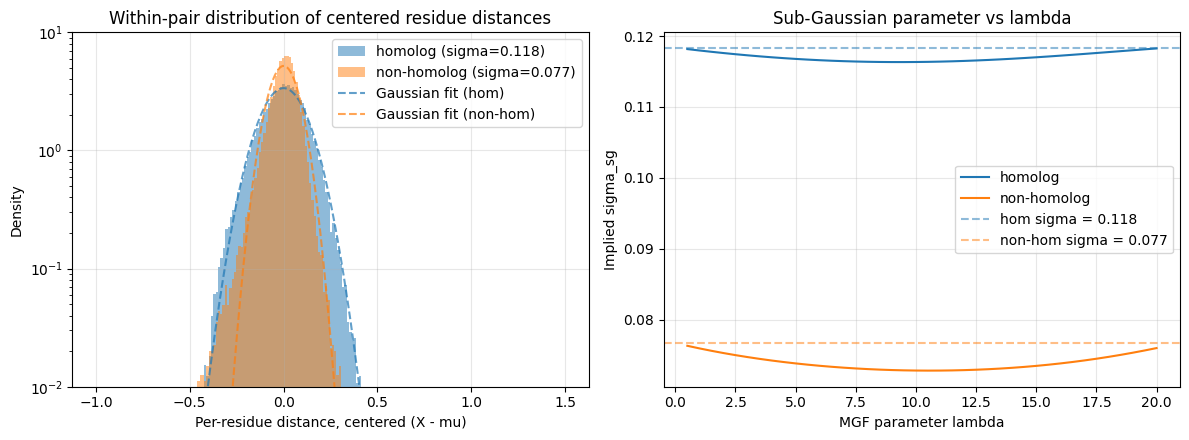

In [20]:
# =============================================================================
# Cell 22: Sub-Gaussian parameter measurement for per-residue distances
# =============================================================================
# The theorem requires that per-residue min-distance distributions (within
# each pair) are sub-Gaussian with parameter sigma_sg. If sigma_sg is close
# to the standard deviation sigma, the sample complexity bound is tight
# (~25 samples). If sigma_sg is much larger (heavy tails), the bound is
# looser.
#
# Method:
#   (1) Empirical MGF: for several lambda, estimate E[exp(lambda*(X - mu))]
#       across the population and check whether it's bounded by exp(sigma_sg^2 * lambda^2 / 2).
#       The smallest sigma_sg that satisfies this for all tested lambda is
#       the sub-Gaussian parameter.
#   (2) Direct tail comparison: for several t, compute the empirical
#       P[X - mu > t] and compare to the Gaussian tail with std = sigma.
#       If empirical tails are heavier, sub-Gaussianity is violated.
#   (3) Variance under non-homolog pairs: needed because theorem uses
#       max(sigma_pos, sigma_neg) and we only measured the homolog side
#       before.
#
# Output: sigma_sg estimate, comparison with sigma, tail behavior verdict,
# and refined sample complexity estimate using the measured constants.

import numpy as np
import matplotlib.pyplot as plt
import math

# Re-encode at full length if full_embs doesn't exist
if "full_embs" not in dir() or full_embs is None:
    @torch.no_grad()
    def _encode_full_length(model, proteins, max_residues=1024):
        model.eval()
        embs = []
        for p in tqdm(proteins, desc="full-length encoding"):
            if len(p.sequence) > max_residues:
                embs.append(None)
                continue
            enc = tokenizer([p.sequence], padding=False, truncation=False,
                            return_tensors="pt").to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda"),
                                    dtype=torch.float16):
                e = model(enc["input_ids"], enc["attention_mask"])
            e = e[0, 1:-1].float().cpu()
            embs.append(e)
            del enc
        return embs
    full_embs = _encode_full_length(model, test_proteins)


# -----------------------------------------------------------------------------
# Build the population of per-residue distances under both pair types
# -----------------------------------------------------------------------------
# For each pair (homolog and non-homolog), the per-residue distribution is
# the set of T_q values {X_i = min_j dist(e^q_i, e^d_j)}.
# We collect all such distributions, centered (X_i - mu(pair)), to study
# the within-pair tail behavior — this is what the theorem actually uses.

def per_residue_dists(qe, de):
    """Return per-residue min cosine distances (T_q,) numpy array."""
    sims = qe @ de.T
    max_sim = sims.max(axis=1)
    return 1.0 - max_sim


# Sample pairs (reuse logic from earlier cells)
by_sf_full = defaultdict(list)
for i, p in enumerate(test_proteins):
    if full_embs[i] is not None and full_embs[i].size(0) >= 30:
        by_sf_full[p.superfamily].append(i)
valid_sfs = [sf for sf, idxs in by_sf_full.items() if len(idxs) >= 2]
all_valid = [i for sf in valid_sfs for i in by_sf_full[sf]]

N_PAIRS = 300  # more pairs for tighter MGF estimates
rng_pairs = random.Random(SEED)

hom_pair_dists = []   # list of (T_q,) arrays, one per homolog pair
nonhom_pair_dists = []

for _ in range(N_PAIRS):
    sf = rng_pairs.choice(valid_sfs)
    i, j = rng_pairs.sample(by_sf_full[sf], 2)
    qe = full_embs[i].numpy()
    de = full_embs[j].numpy()
    hom_pair_dists.append(per_residue_dists(qe, de))

for _ in range(N_PAIRS):
    i = rng_pairs.choice(all_valid)
    sf_i = test_proteins[i].superfamily
    while True:
        j = rng_pairs.choice(all_valid)
        if test_proteins[j].superfamily != sf_i:
            break
    qe = full_embs[i].numpy()
    de = full_embs[j].numpy()
    nonhom_pair_dists.append(per_residue_dists(qe, de))


# Per-pair statistics
hom_means = np.array([d.mean() for d in hom_pair_dists])
hom_vars = np.array([d.var() for d in hom_pair_dists])
nonhom_means = np.array([d.mean() for d in nonhom_pair_dists])
nonhom_vars = np.array([d.var() for d in nonhom_pair_dists])

print("=" * 78)
print("  Per-pair statistics (n=%d each)" % N_PAIRS)
print("=" * 78)
print(f"\n{'':>20} {'median mu':>12} {'p95 mu':>12} {'median sigma^2':>16} "
      f"{'p95 sigma^2':>12}")
print(f"{'homolog':>20} {np.median(hom_means):>12.4f} "
      f"{np.percentile(hom_means, 95):>12.4f} "
      f"{np.median(hom_vars):>16.4f} {np.percentile(hom_vars, 95):>12.4f}")
print(f"{'non-homolog':>20} {np.median(nonhom_means):>12.4f} "
      f"{np.percentile(nonhom_means, 95):>12.4f} "
      f"{np.median(nonhom_vars):>16.4f} {np.percentile(nonhom_vars, 95):>12.4f}")

# The theorem uses worst-case sigma over pairs. Report p95 as a practical proxy.
sigma_pos_sq = float(np.percentile(hom_vars, 95))
sigma_neg_sq = float(np.percentile(nonhom_vars, 95))
sigma_max_sq = max(sigma_pos_sq, sigma_neg_sq)
sigma_max = math.sqrt(sigma_max_sq)
print(f"\nWorst-case sigma (p95 over pairs):")
print(f"  homolog:     sigma = {math.sqrt(sigma_pos_sq):.4f}")
print(f"  non-homolog: sigma = {math.sqrt(sigma_neg_sq):.4f}")
print(f"  max:         sigma = {sigma_max:.4f}")


# -----------------------------------------------------------------------------
# (1) Empirical MGF: pool centered residue distances across pairs
# -----------------------------------------------------------------------------
# To estimate the sub-Gaussian parameter, pool all centered residue distances
# (X_i - mu_pair) across pairs. This treats the per-residue distance
# distribution as a mixture; the sub-Gaussian parameter of the mixture
# upper-bounds that of any component.
#
# For X to be sigma_sg-sub-Gaussian, we need
#   E[exp(lambda * (X - mu))] <= exp(sigma_sg^2 * lambda^2 / 2)  for all lambda
# Take log: log MGF <= sigma_sg^2 * lambda^2 / 2
# The implied sigma_sg from a single lambda is sqrt(2 * log_mgf / lambda^2).
# The actual sub-Gaussian parameter is the sup of this over lambda.

def empirical_log_mgf(centered, lambdas):
    """Return log E[exp(lambda * X)] for each lambda."""
    # Use logsumexp for stability
    out = []
    for lam in lambdas:
        z = lam * centered
        z_max = z.max()
        log_mgf = z_max + np.log(np.mean(np.exp(z - z_max)))
        out.append(log_mgf)
    return np.array(out)


def estimate_sigma_sg(centered, lambdas):
    """For each lambda, sigma_sg implied by 2*log_mgf/lambda^2. Returns array."""
    log_mgf = empirical_log_mgf(centered, lambdas)
    # Clamp non-positive MGFs (shouldn't happen for centered data with lambda > 0
    # except by sampling noise); they imply sigma_sg = 0.
    log_mgf = np.maximum(log_mgf, 0.0)
    return np.sqrt(2 * log_mgf / lambdas ** 2)


def analyze_subgauss(pair_dists, label):
    print(f"\n--- Sub-Gaussian analysis: {label} ---")
    # Pool centered distances
    centered_list = [d - d.mean() for d in pair_dists]
    centered = np.concatenate(centered_list)
    sigma_emp = float(centered.std())
    print(f"  Pooled n = {len(centered)} residues")
    print(f"  Empirical std (sigma):     {sigma_emp:.4f}")
    print(f"  Empirical sigma^2:         {sigma_emp**2:.4f}")
    print(f"  Empirical min/max centered: [{centered.min():.3f}, "
          f"{centered.max():.3f}]")

    # Try a range of lambda values. For sub-Gaussian with sigma ~ 0.1, the
    # informative range is roughly lambda in [1, 30].
    lambdas = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0])
    sg = estimate_sigma_sg(centered, lambdas)
    print(f"\n  Implied sigma_sg(lambda):")
    print(f"  {'lambda':>8} {'implied sigma_sg':>18} {'ratio to sigma':>16}")
    for lam, s in zip(lambdas, sg):
        print(f"  {lam:>8.1f} {s:>18.4f} {s/sigma_emp:>16.2f}")
    sigma_sg_est = float(sg.max())
    print(f"\n  Sub-Gaussian parameter estimate (sup over lambda): "
          f"sigma_sg = {sigma_sg_est:.4f}")
    print(f"  Ratio sigma_sg / sigma: {sigma_sg_est / sigma_emp:.2f}")
    print(f"  (=1 means perfectly Gaussian, >1 means heavier-tailed)")
    return sigma_emp, sigma_sg_est, centered


print("\n" + "=" * 78)
print("  Sub-Gaussian parameter estimation")
print("=" * 78)
sigma_h, sigma_sg_h, centered_h = analyze_subgauss(hom_pair_dists, "homolog pairs")
sigma_n, sigma_sg_n, centered_n = analyze_subgauss(nonhom_pair_dists,
                                                    "non-homolog pairs")


# -----------------------------------------------------------------------------
# (2) Direct tail comparison: empirical vs Gaussian tail
# -----------------------------------------------------------------------------
# For several t, compute P[X - mu > t] empirically and compare with the
# Gaussian tail Phi_bar(t/sigma). If empirical is much larger, tails are
# heavier than Gaussian and sigma_sg > sigma.
def gaussian_tail(t, sigma):
    # P[Z > t/sigma] for standard normal Z; use erfc for stability
    from math import erfc
    return 0.5 * erfc(t / (sigma * math.sqrt(2)))


def tail_comparison(centered, sigma, label):
    print(f"\n--- Upper tail comparison: {label} ---")
    print(f"  {'t':>6} {'t/sigma':>9} {'emp P[X-mu>t]':>15} "
          f"{'Gaussian tail':>15} {'ratio':>10}")
    ts = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5]
    for t in ts:
        emp = float((centered > t).mean())
        gauss = gaussian_tail(t, sigma)
        ratio = emp / gauss if gauss > 0 else float("inf")
        if emp == 0:
            print(f"  {t:>6.2f} {t/sigma:>9.2f} {'< 1/' + str(len(centered)):>15} "
                  f"{gauss:>15.2e} {'<':>10}")
        else:
            print(f"  {t:>6.2f} {t/sigma:>9.2f} {emp:>15.2e} "
                  f"{gauss:>15.2e} {ratio:>10.2f}")


tail_comparison(centered_h, sigma_h, "homolog pairs")
tail_comparison(centered_n, sigma_n, "non-homolog pairs")


# -----------------------------------------------------------------------------
# (3) Implications for the theorem
# -----------------------------------------------------------------------------
# Sample complexity (sub-Gaussian classification bound):
#   s >= 2 * sigma_sg^2 * ln(2N/delta) / min(tau - mu_pos, mu_neg - tau)^2
sigma_sg = max(sigma_sg_h, sigma_sg_n)
mu_pos = float(np.median(hom_means))
mu_neg = float(np.median(nonhom_means))
gap = mu_neg - mu_pos
tau = (mu_pos + mu_neg) / 2  # symmetric threshold
margin = gap / 2

# Conservative version: use p95 worst-case
mu_pos_worst = float(np.percentile(hom_means, 95))
mu_neg_worst = float(np.percentile(nonhom_means, 5))
gap_worst = mu_neg_worst - mu_pos_worst
margin_worst = gap_worst / 2

N_DB = [1_000, 10_000, 100_000, 1_000_000]
DELTA = 0.01

print("\n" + "=" * 78)
print("  Sample complexity from the measured constants")
print("=" * 78)
print(f"\nMedian gap:    mu_pos = {mu_pos:.4f}, mu_neg = {mu_neg:.4f}, "
      f"margin = {margin:.4f}")
print(f"P95 worst gap: mu_pos = {mu_pos_worst:.4f}, mu_neg = "
      f"{mu_neg_worst:.4f}, margin = {margin_worst:.4f}")
print(f"sigma_sg used: {sigma_sg:.4f}")
print(f"\n{'N':>10} {'s (median gap)':>16} {'s (p95 worst gap)':>20} "
      f"{'speedup vs Tq=200':>18}")
for N in N_DB:
    s_med = math.ceil(2 * sigma_sg**2 * math.log(2 * N / DELTA) / margin**2)
    s_worst = math.ceil(2 * sigma_sg**2 * math.log(2 * N / DELTA)
                        / max(margin_worst, 1e-6)**2)
    print(f"{N:>10} {s_med:>16} {s_worst:>20} {200/max(s_med, 1):>18.1f}x")

# Compare with Bakshi (worst-case Hoeffding for estimation at same epsilon)
B = 2.0
print(f"\nFor reference:")
print(f"  Bakshi (Hoeffding worst-case, eps = margin = {margin:.4f}, N=10^6):")
s_bakshi = math.ceil(B**2 * math.log(2 * 1_000_000 / DELTA) / (2 * margin**2))
print(f"    s = {s_bakshi}")
print(f"  Our bound (sub-Gaussian + gap framing):")
s_ours = math.ceil(2 * sigma_sg**2 * math.log(2 * 1_000_000 / DELTA) / margin**2)
print(f"    s = {s_ours}")
print(f"  Theoretical improvement factor: {s_bakshi / max(s_ours, 1):.1f}x")


# -----------------------------------------------------------------------------
# (4) Plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: histogram of centered distances vs fitted Gaussian
ax = axes[0]
ax.hist(centered_h, bins=80, density=True, alpha=0.5, color="C0",
        label=f"homolog (sigma={sigma_h:.3f})")
ax.hist(centered_n, bins=80, density=True, alpha=0.5, color="C1",
        label=f"non-homolog (sigma={sigma_n:.3f})")
# Overlay Gaussians
xs = np.linspace(-1, 1.5, 300)
ax.plot(xs, np.exp(-xs**2 / (2*sigma_h**2)) / (sigma_h * math.sqrt(2*math.pi)),
        "C0--", alpha=0.7, label="Gaussian fit (hom)")
ax.plot(xs, np.exp(-xs**2 / (2*sigma_n**2)) / (sigma_n * math.sqrt(2*math.pi)),
        "C1--", alpha=0.7, label="Gaussian fit (non-hom)")
ax.set_xlabel("Per-residue distance, centered (X - mu)")
ax.set_ylabel("Density")
ax.set_title("Within-pair distribution of centered residue distances")
ax.set_yscale("log")
ax.set_ylim(0.01, 10)
ax.legend()
ax.grid(alpha=0.3)

# Right: implied sigma_sg as a function of lambda
ax = axes[1]
lambdas = np.linspace(0.5, 20, 40)
sg_h = estimate_sigma_sg(centered_h, lambdas)
sg_n = estimate_sigma_sg(centered_n, lambdas)
ax.plot(lambdas, sg_h, color="C0", label="homolog")
ax.plot(lambdas, sg_n, color="C1", label="non-homolog")
ax.axhline(sigma_h, color="C0", linestyle="--", alpha=0.5,
           label=f"hom sigma = {sigma_h:.3f}")
ax.axhline(sigma_n, color="C1", linestyle="--", alpha=0.5,
           label=f"non-hom sigma = {sigma_n:.3f}")
ax.set_xlabel("MGF parameter lambda")
ax.set_ylabel("Implied sigma_sg")
ax.set_title("Sub-Gaussian parameter vs lambda")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("subgaussian_measurement.png", dpi=100)
plt.show()